The pr-work #7

First name - Rodion

Second name - Ostapenko

Group - CS-24

In [49]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import umap

from sklearn.ensemble import RandomForestClassifier

### Load the data

In [50]:
drugs_df = pd.read_csv(r"C:\Users\rodio\PycharmProjects\DataMining\src\ML_ready_drug_dataset.csv")
drugs_df.head(10)

,Age,Na_to_K,BP_encoded,Cholesterol_encoded,Sex_M,Drug_encoded
0,-1.291591,1.286522,2,1,0,0
1,0.162699,-0.415145,0,1,1,3
2,0.162699,-0.828558,0,1,1,3
3,-0.988614,-1.149963,1,1,0,4
4,1.011034,0.271794,0,1,0,0
5,-1.352186,-1.037693,1,1,0,4
6,0.283889,0.026439,1,1,0,0
7,-0.200874,-0.700468,0,1,1,3
8,0.950439,-0.126770,1,1,1,0
9,-0.079683,0.455672,0,0,1,0


In [51]:
drugs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  200 non-null    float64
 1   Na_to_K              200 non-null    float64
 2   BP_encoded           200 non-null    int64  
 3   Cholesterol_encoded  200 non-null    int64  
 4   Sex_M                200 non-null    int64  
 5   Drug_encoded         200 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 9.5 KB


### Visualize the data

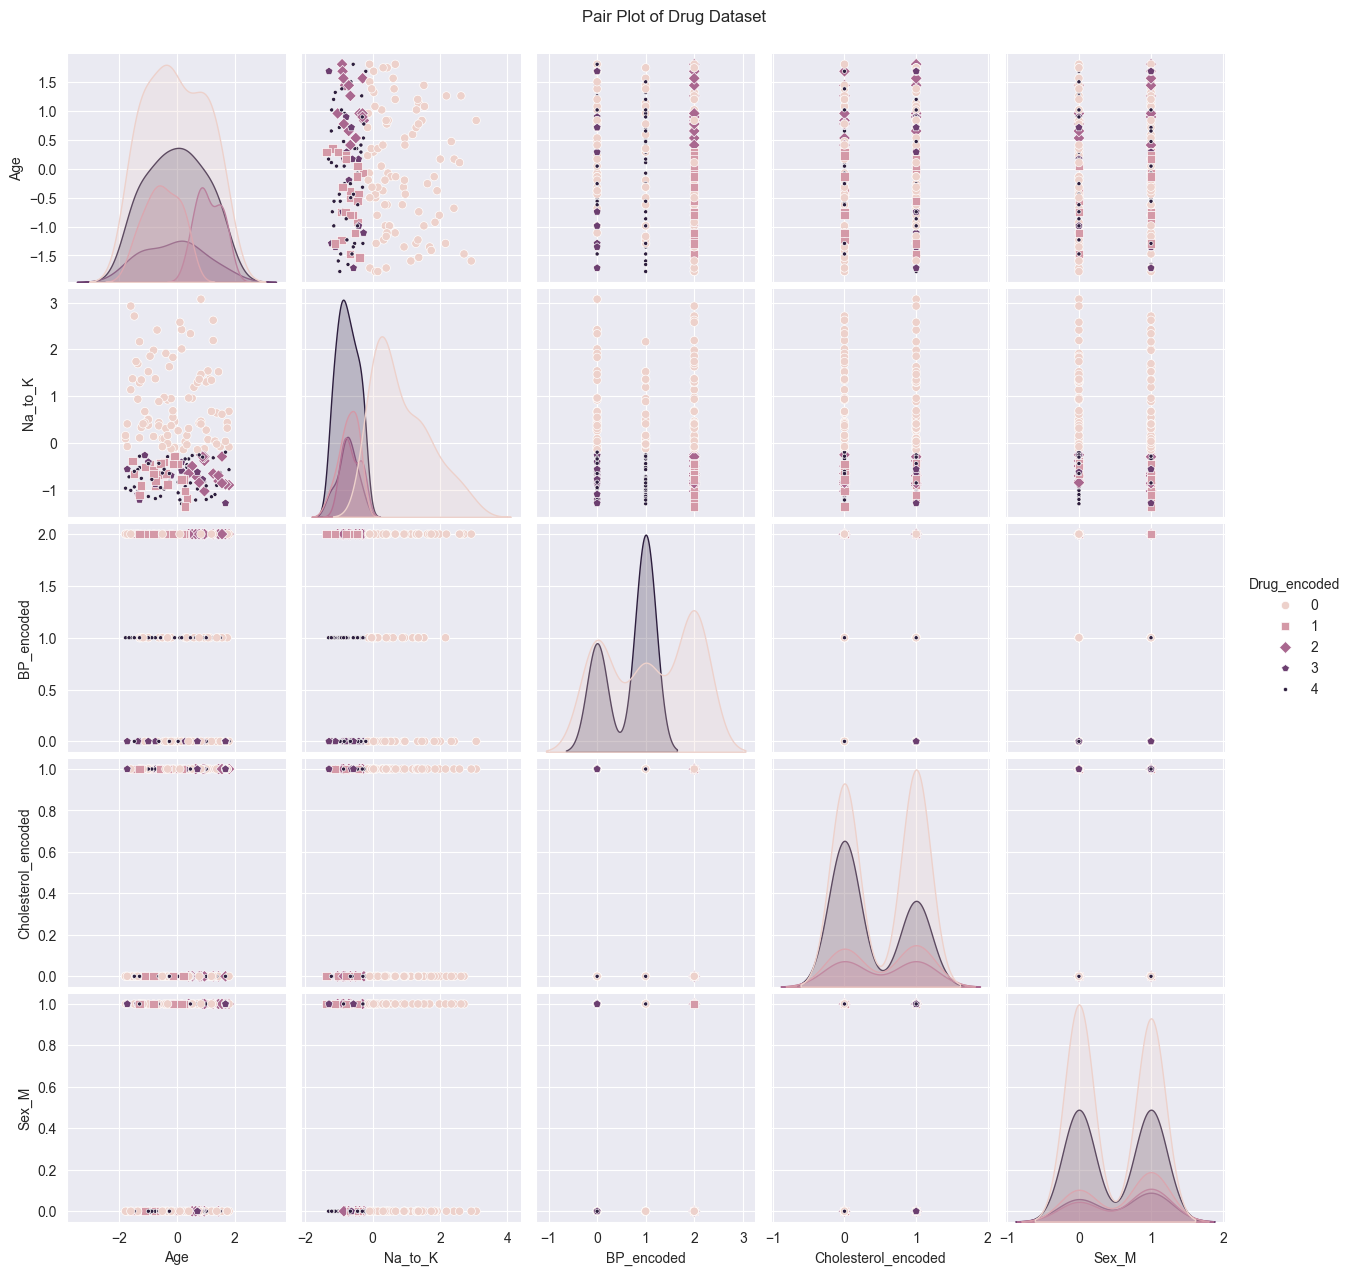

In [52]:
sns.pairplot(drugs_df, hue='Drug_encoded', markers=["o", "s", "D", "p", "."])
plt.suptitle("Pair Plot of Drug Dataset", y=1.02)
plt.show()

### I. Data Splitting and Baseline

In [53]:
x = drugs_df.drop(columns=['Drug_encoded'])
y = drugs_df['Drug_encoded']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4)

baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(x_train, y_train)
baseline_score = baseline_model.score(x_test, y_test)
print(f"Baseline Accuracy: {baseline_score}")

Baseline Accuracy: 0.375


### II. Training Basic Models

In [54]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)

rf_model.fit(x_train_scaled, y_train)
knn_model.fit(x_train_scaled, y_train)

rf_pred = rf_model.predict(x_test_scaled)
knn_pred = knn_model.predict(x_test_scaled)

### III. Model Evaluation

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       0.86      1.00      0.92         6
           2       1.00      0.67      0.80         3
           3       1.00      1.00      1.00         5
           4       1.00      0.91      0.95        11

    accuracy                           0.95        40
   macro avg       0.96      0.92      0.93        40
weighted avg       0.96      0.95      0.95        40

RF Train Score: 1.00
RF Test Score: 0.95
--- KNN Report ---
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        15
           1       0.75      0.50      0.60         6
           2       1.00      0.67      0.80         3
           3       1.00      0.80      0.89         5
           4       0.71      0.91      0.80        11

    accuracy                           0.78        40
   macro avg       0.84      0.74      0.7

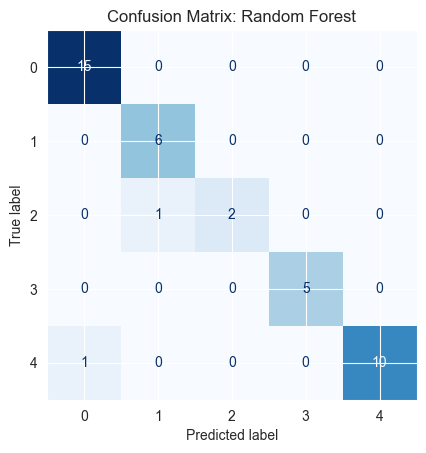

In [55]:
print("--- Random Forest Report ---")
print(classification_report(y_test, rf_pred))

print(f"RF Train Score: {rf_model.score(x_train_scaled, y_train):.2f}")
print(f"RF Test Score: {rf_model.score(x_test_scaled, y_test):.2f}")

print("--- KNN Report ---")
print(classification_report(y_test, knn_pred))

print(f"KNN Train Score: {knn_model.score(x_train_scaled, y_train):.2f}")
print(f"KNN Test Score: {knn_model.score(x_test_scaled, y_test):.2f}")


disp = ConfusionMatrixDisplay.from_estimator(
    rf_model, x_test_scaled, y_test, 
    cmap=plt.cm.Blues, 
    colorbar=False
)
plt.title("Confusion Matrix: Random Forest")
plt.show()

#### 1. The "Why" in Metrics

For a medical dataset predicting drug prescriptions, assigning the wrong medication can have severe clinical consequences. Because the dataset is highly imbalanced (class 0 has 15 instances, class 2 has only 3), pure accuracy is misleading. F1-Score is the most critical metric here. It gives equal weight to all classes regardless of their size, ensuring that the model doesn't just learn to predict the most common drugs while completely failing on rare, specialized prescriptions.

#### 2. Overfitting/Underfitting Analysis

Random Forest: The model perfectly memorized the training data, which is technically overfitting, but because the Test Score is extremely high, it proved capable of generalizing excellently to unseen data.
KNN: The model shows clear signs of overfitting and poor generalization. The 15% drop from the Train Score to the Test Score indicates it memorized specific local data points rather than learning actual underlying patterns for drug classification.

#### 3. The Final Verdict

I would deploy the Random Forest model to production. It decisively outperforms KNN across every metric, achieving a 95% overall accuracy and a 0.93 F1-score compared to KNN's 0.77. In a medical context, KNN's 22% error rate is dangerously high. Furthermore, Random Forest successfully identified minority classes(like class 3 with 1.00 F1-score), proving it can reliably handle rare drug prescriptions.

### N. Make data visualizations


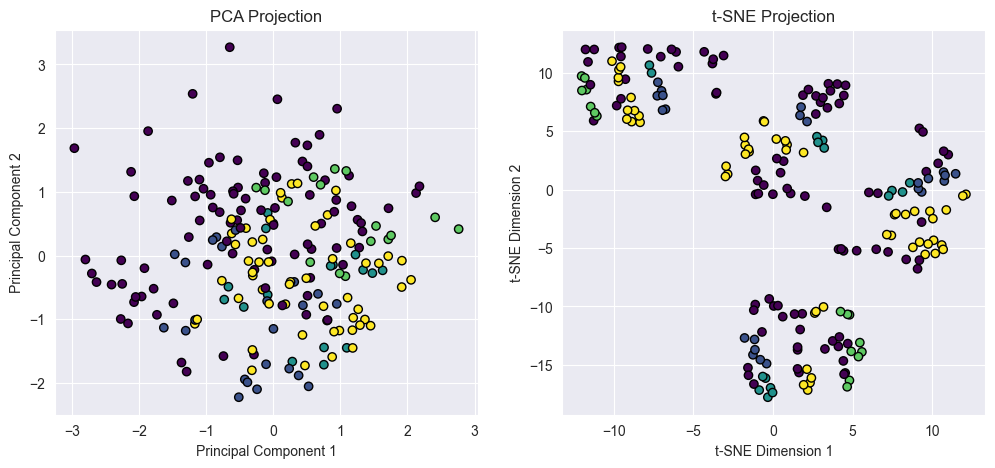

In [56]:
X_scaled = scaler.fit_transform(x)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k')
ax1.set_title('PCA Projection')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')

scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', edgecolor='k')
ax2.set_title('t-SNE Projection')
ax2.set_xlabel('t-SNE Dimension 1')
ax2.set_ylabel('t-SNE Dimension 2')

plt.show()

In [57]:
reducer = umap.UMAP(n_components=3, n_neighbors=15, random_state=42)
X_3d = reducer.fit_transform(X_scaled)

df_3d = pd.DataFrame(X_3d, columns=['UMAP_1', 'UMAP_2', 'UMAP_3'])
df_3d['Class'] = y

fig = px.scatter_3d(
    df_3d, 
    x='UMAP_1', 
    y='UMAP_2', 
    z='UMAP_3',
    color='Class',
    title="UMAP Projection",
    opacity=0.8,
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_traces(marker=dict(size=4))
fig.show()

C:\Users\rodio\PycharmProjects\DataMining\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### IV. Bonus Task

In [58]:
dimensions = [2, 3, 5]
results = []

model = RandomForestClassifier(random_state=42)

for dim in dimensions:
    pca = PCA(n_components=dim)
    X_train_pca = pca.fit_transform(x_train_scaled)
    X_test_pca = pca.transform(x_test_scaled)
    
    model.fit(X_train_pca, y_train)
    pca_score = accuracy_score(y_test, model.predict(X_test_pca))
    
    
    reducer = umap.UMAP(n_components=dim, random_state=42)
    X_train_umap = reducer.fit_transform(x_train_scaled)
    X_test_umap = reducer.transform(x_test_scaled)
    
    model.fit(X_train_umap, y_train)
    umap_score = accuracy_score(y_test, model.predict(X_test_umap))
    
    
    tsne_method = 'barnes_hut' if dim < 4 else 'exact'
    tsne = TSNE(n_components=dim, random_state=42, method=tsne_method)
    X_tsne_all = tsne.fit_transform(X_scaled)
    X_train_tsne, X_test_tsne, y_train_t, y_test_t = train_test_split(
        X_tsne_all, y, test_size=0.2, random_state=42, stratify=y
    )
    
    model.fit(X_train_tsne, y_train_t)
    tsne_score = accuracy_score(y_test_t, model.predict(X_test_tsne))
    
    
    results.append({
        'Dimensions': dim,
        'PCA Accuracy': pca_score,
        'UMAP Accuracy': umap_score,
        't-SNE Accuracy': tsne_score
    })

results_df = pd.DataFrame(results)
results_df

C:\Users\rodio\PycharmProjects\DataMining\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\rodio\PycharmProjects\DataMining\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\rodio\PycharmProjects\DataMining\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,Dimensions,PCA Accuracy,UMAP Accuracy,t-SNE Accuracy
0,2,0.45,0.400,0.700
1,3,0.65,0.575,0.775
2,5,0.90,0.625,0.750


#### PCA shows a drastic, linear improvement as dimensions increase (from 0.45 in 2D to 0.90 in 5D).

The variance responsible for separating your classes is not concentrated in just one or two principal components; it is distributed across multiple axes. At 2D and 3D, PCA severely underfits because it drops critical linear features. However, once given 5 dimensions, it captures enough of the dataset's underlying geometry to outperform the other methods.

#### t-SNE shows the strongest performance at low dimensions (0.700 in 2D and 0.775 in 3D), but plateaus and slightly degrades at 5D (0.750).

t-SNE does not benefit from higher dimensions. Also there was a data leakage when fitting the entire dataset before the train/test split. The high low-dimensional accuracy proves t-SNE is good for visualizing the data, but the metrics themselves are invalid for assessing well predictive performance.

#### UMAP consistently performs the worst across all dimensional thresholds, peaking at only 0.625 in 5D.

For my dataset, UMAP's non-linear manifold learning is actively destroying the topological features that my model relies on to separate classes.


### Final Conclusions on Applicability

1. For Feature Engineering: PCA at 5+ dimensions is the only viable option here
2. For Visualization: t-SNE is the best tool. 
3. Methods to Discard: UMAP should not be used for my specific dataset, neither for feature extraction nor visualization.